```
Yulu-Bikes
```

#Problem statement:-
Yulu has recently suffered considerable dips in its revenues.

The company wants to know:
Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
How well those variables describe the electric cycle demands.  





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import datetime
from scipy.stats import norm,ttest_1samp,ttest_ind,ttest_rel
from scipy.stats import f_oneway,kruskal,shapiro,levene,chi2_contingency
from statsmodels.graphics.gofplots import qqplot

In [ ]:
!gdown 1SBrGVIOigjUNnUL0W6N0qyuxlxANXsN6

Downloading...
From: https://drive.google.com/uc?id=1SBrGVIOigjUNnUL0W6N0qyuxlxANXsN6
To: /content/bike_sharing_yulu.txt
100% 648k/648k [00:00<00:00, 101MB/s]


In [ ]:
data=pd.read_csv('bike_sharing_yulu.txt')

In [ ]:
data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
data.shape

(10886, 12)

In [ ]:
data.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
data['datetime']=data.datetime.astype('category')

In [ ]:
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df=data.copy()
for i in ('season','holiday','workingday','weather'):
  df[i]=df[i].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   datetime    10886 non-null  category
 1   season      10886 non-null  category
 2   holiday     10886 non-null  category
 3   workingday  10886 non-null  category
 4   weather     10886 non-null  category
 5   temp        10886 non-null  float64 
 6   atemp       10886 non-null  float64 
 7   humidity    10886 non-null  int64   
 8   windspeed   10886 non-null  float64 
 9   casual      10886 non-null  int64   
 10  registered  10886 non-null  int64   
 11  count       10886 non-null  int64   
dtypes: category(5), float64(3), int64(4)
memory usage: 1003.0 KB


In [ ]:
data.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
print("total seasons and their records",data.season.value_counts())
print("total holidays and their records",data.holiday.value_counts())
print("total workingdays and their records",data.workingday.value_counts())
print("total weather and their records",data.weather.value_counts())

total seasons and their records season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
total holidays and their records holiday
0    10575
1      311
Name: count, dtype: int64
total workingdays and their records workingday
1    7412
0    3474
Name: count, dtype: int64
total weather and their records weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [ ]:
df['datetime']=pd.to_datetime(df['datetime'])
df['date']=df['datetime'].dt.date
df['time']=df['datetime'].dt.time
display(df.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,00:00:00
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,01:00:00
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,02:00:00
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,03:00:00
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,04:00:00


# Distribution of variables:-
1. **Univariate analysis**:


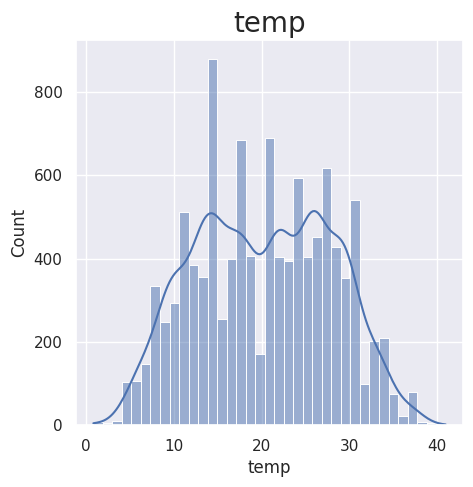

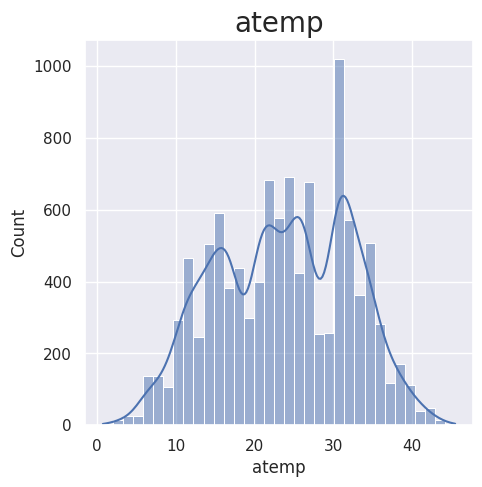

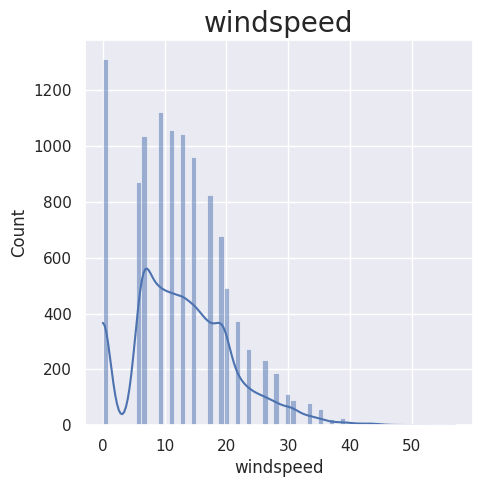

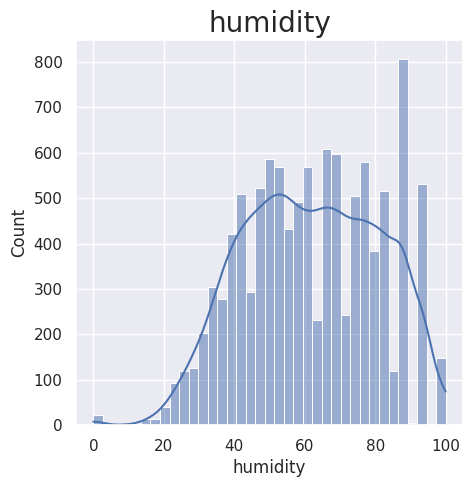

In [ ]:
columns=['temp','atemp', 'windspeed','humidity']
for i in columns:
  plt.figure(figsize=(5,5))
  plt.title(i,fontsize=20)
  sns.histplot(data[i],kde=True)
  plt.show()

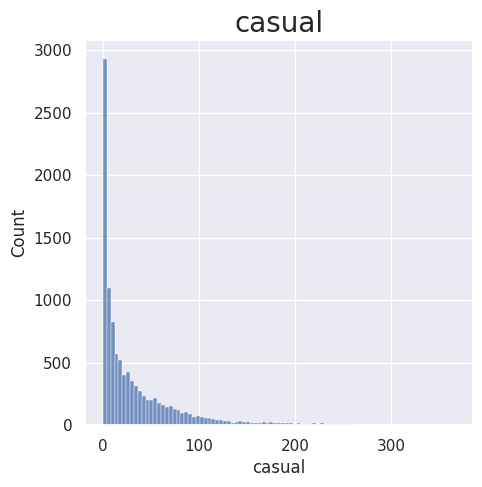

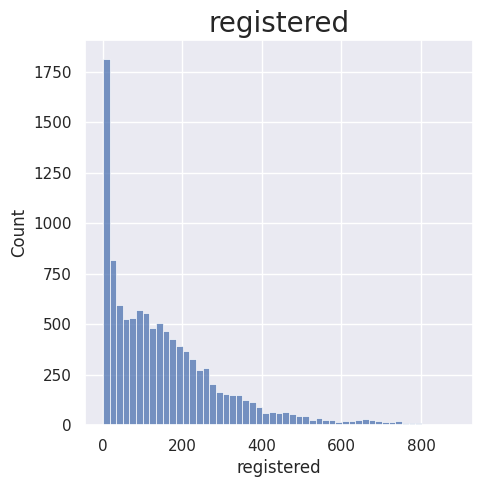

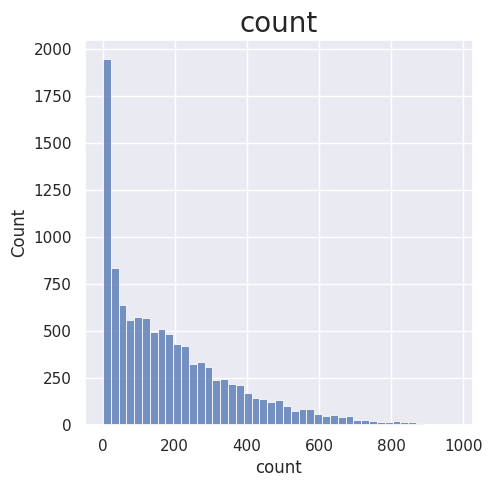

In [ ]:
columns=['casual', 'registered', 'count']
for i in columns:
  plt.figure(figsize=(5,5))
  plt.title(i,fontsize=20)
  sns.histplot(data[i])
  plt.show()

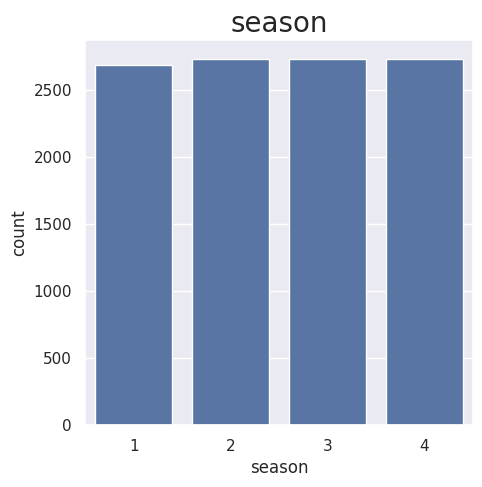

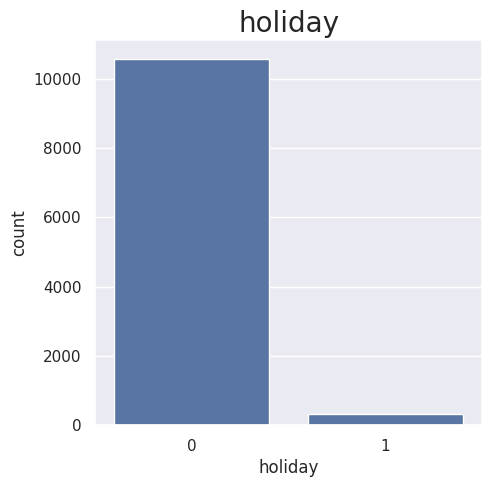

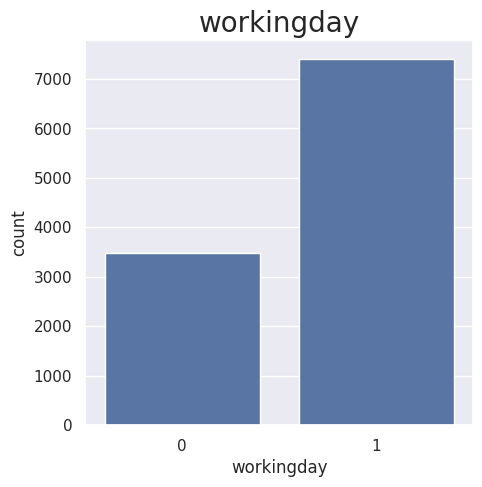

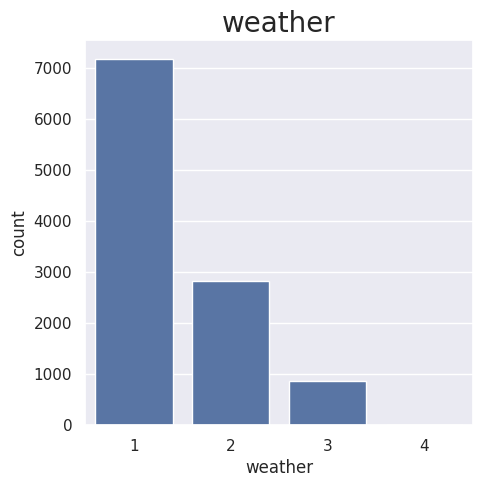

In [ ]:
columns=['season', 'holiday', 'workingday', 'weather']
for i in columns:
  plt.figure(figsize=(5,5))
  plt.title(i,fontsize=20)
  sns.countplot(data=data,x=i)
  plt.show()

#Outlier detection

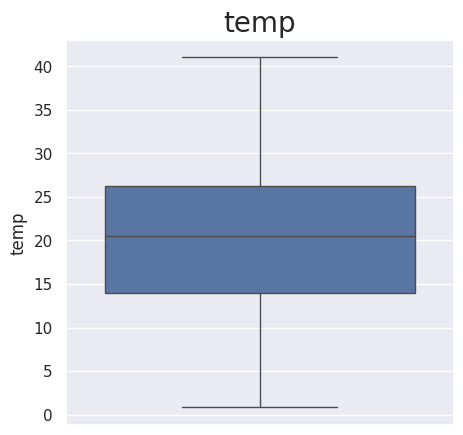

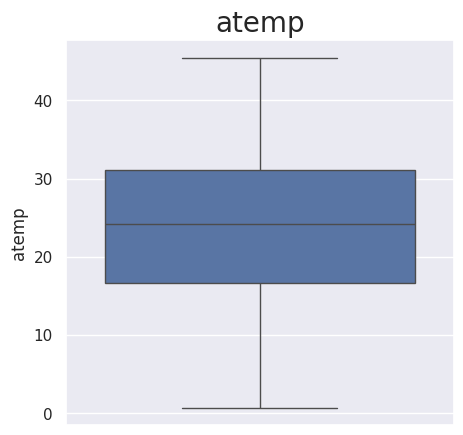

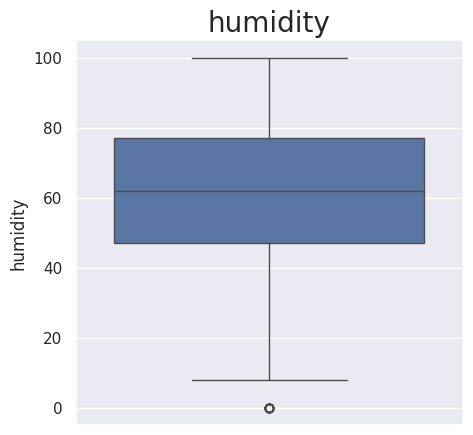

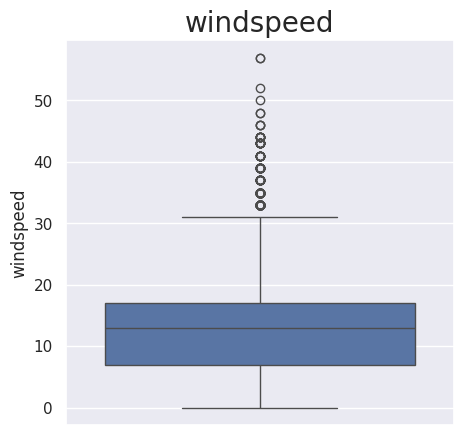

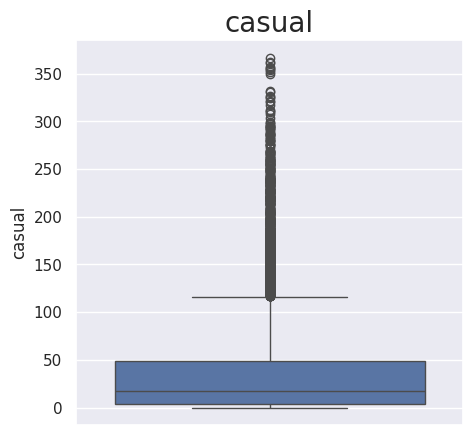

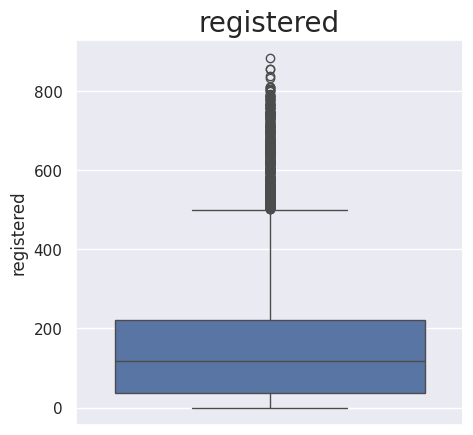

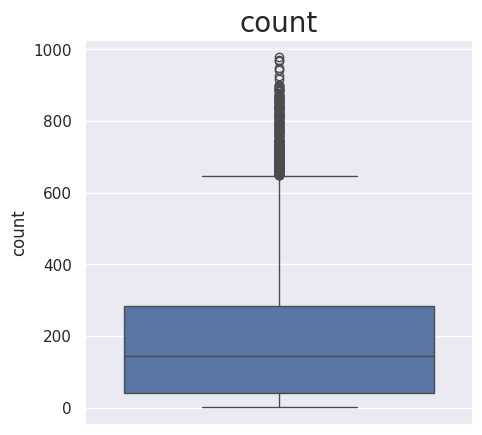

In [ ]:
columns=['temp','atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
for i in columns:
  plt.figure(figsize=(5,5))
  plt.title(i,fontsize=20)
  sns.boxplot(data[i])
  plt.show()

In [ ]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


In [ ]:
#for casual column:
q1=df.casual.quantile(0.25)
q3=df.casual.quantile(0.75)
iqr=q3-q1
print(q1,q3,iqr)
upper=q3+1.5*iqr
lower=q1-1.5*iqr
print(upper,lower)
print(df[df.casual==df.casual.quantile(0.90)].count())
print(df[df.casual==df.casual.quantile(0.01)].count())

4.0 49.0 45.0
116.5 -63.5
datetime      18
season        18
holiday       18
workingday    18
weather       18
temp          18
atemp         18
humidity      18
windspeed     18
casual        18
registered    18
count         18
date          18
time          18
dtype: int64
datetime      986
season        986
holiday       986
workingday    986
weather       986
temp          986
atemp         986
humidity      986
windspeed     986
casual        986
registered    986
count         986
date          986
time          986
dtype: int64


In [ ]:
df['casual']=np.clip(df['casual'],df['casual'].quantile(0.01),df['casual'].quantile(0.90))
df['registered']=np.clip(df['registered'],df['registered'].quantile(0.01),df['registered'].quantile(0.95))
df['count']=np.clip(df['count'],df['count'].quantile(0.01),df['count'].quantile(0.95))

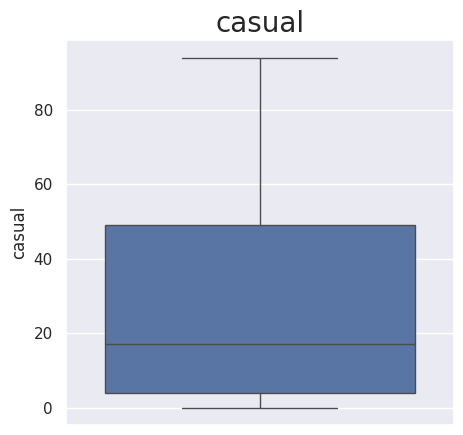

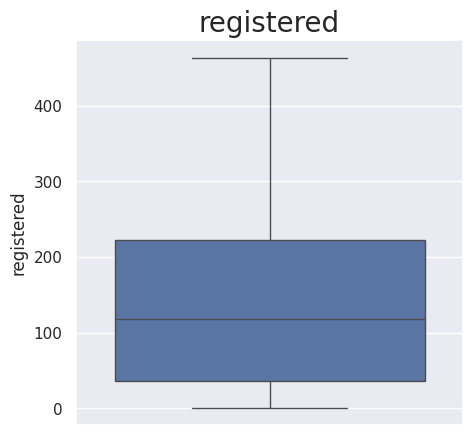

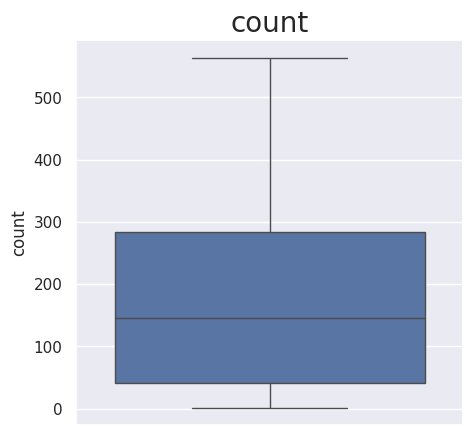

In [ ]:
#box plot for treated outliers:-
columns=['casual', 'registered', 'count']
for i in columns:
  plt.figure(figsize=(5,5))
  plt.title(i,fontsize=20)
  sns.boxplot(df[i])
  plt.show()

In [ ]:
#Outliers has been treated:-
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,29.648907,148.867261,185.583663
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,94.000000,464.000000,563.750000
std,NaN,7.79159,8.474601,19.245033,8.164537,31.360649,131.329346,164.707643


*Bivariate analysis*

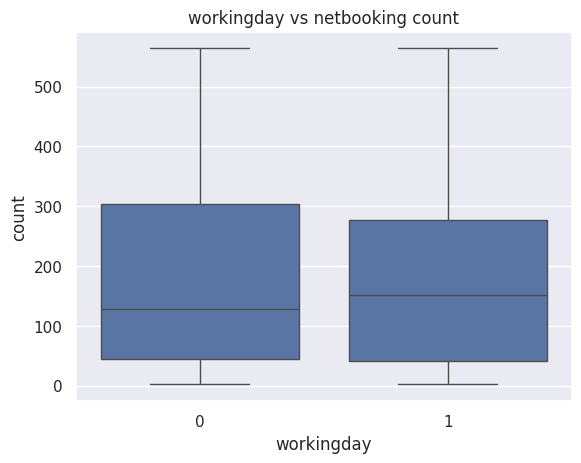

In [ ]:

sns.boxplot(data=df,x='workingday',y='count')
plt.title('workingday vs netbooking count')
plt.show()

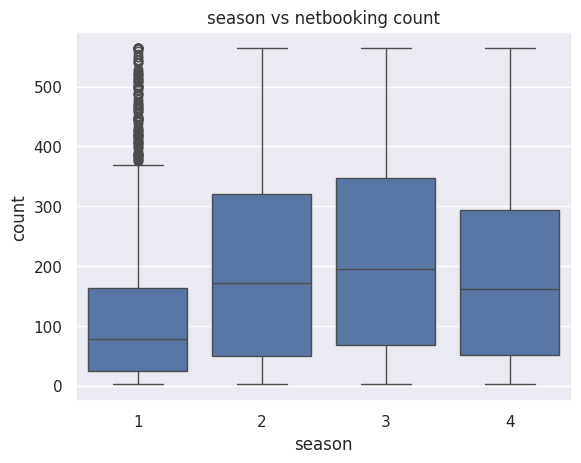

In [ ]:
sns.boxplot(data=df,x='season',y='count')
plt.title('season vs netbooking count')
plt.show()

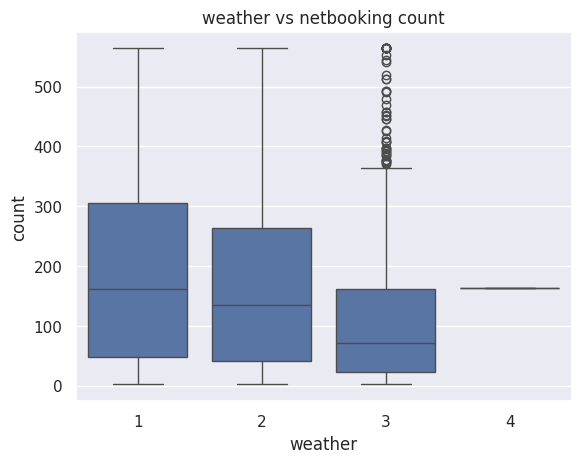

In [ ]:
sns.boxplot(data=df,x='weather',y='count')
plt.title('weather vs netbooking count')
plt.show()

In [ ]:
data.drop('datetime',axis=1,inplace=True)


In [ ]:
np.round(data.corr(),2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.00,0.03,-0.01,0.01,0.26,0.26,0.19,-0.15,0.10,0.16,0.16
holiday,0.03,1.00,-0.25,-0.01,0.00,-0.01,0.00,0.01,0.04,-0.02,-0.01
workingday,-0.01,-0.25,1.00,0.03,0.03,0.02,-0.01,0.01,-0.32,0.12,0.01
weather,0.01,-0.01,0.03,1.00,-0.06,-0.06,0.41,0.01,-0.14,-0.11,-0.13
temp,0.26,0.00,0.03,-0.06,1.00,0.98,-0.06,-0.02,0.47,0.32,0.39
atemp,0.26,-0.01,0.02,-0.06,0.98,1.00,-0.04,-0.06,0.46,0.31,0.39
humidity,0.19,0.00,-0.01,0.41,-0.06,-0.04,1.00,-0.32,-0.35,-0.27,-0.32
windspeed,-0.15,0.01,0.01,0.01,-0.02,-0.06,-0.32,1.00,0.09,0.09,0.10
casual,0.10,0.04,-0.32,-0.14,0.47,0.46,-0.35,0.09,1.00,0.50,0.69
registered,0.16,-0.02,0.12,-0.11,0.32,0.31,-0.27,0.09,0.50,1.00,0.97


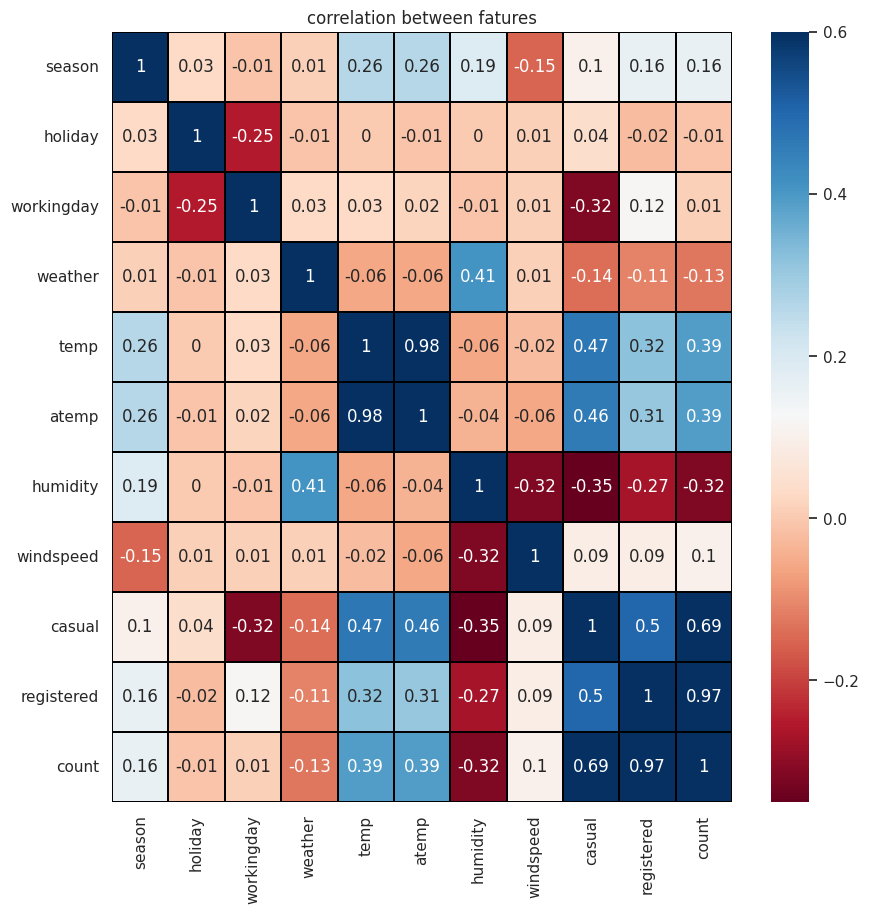

In [ ]:
sns.set(font_scale=1.0)
plt.figure(figsize=(10,10))
corr_val=np.round(data.corr(),2)
sns.heatmap(corr_val,annot=True,cmap='RdBu',linecolor='black',linewidths=0.01,vmax=0.6)
plt.title('correlation between fatures')
plt.show()

In [ ]:
data.drop('atemp',axis=1,inplace=True)
df.drop('atemp',axis=1,inplace=True)

#Data insights :->

1. a.10886 entries and total 12 columns.

   b.float64(3), int64(8), object(1)

    c. Total 12 attributes(columns) are ->

    1. **datetime**: string tells date and time of booking bikes.

    2. **season**:berief about seasons
             
      1: spring

      2: summer
      
      3: fall

      4: winter

    3. **holiday**:  0 if day is a holiday and 1 if not.
     
    4. **workingday**: if day is neither weekend nor holiday is 1, otherwise is 0.
    
    5. **weather**:categorise weather condition in 4 categories-
       
       1: Clear, Few clouds, partly cloudy.
       
       2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist.

       3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds.
       
       4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog.

    6. **temp**: temperature in Celsius.

    7. **atemp**: feeling temperature in Celsius.

    8. **humidity**: humidity

    9. **windspeed**: wind speed

    10. **casual**: count of casua users.

    11. **registered**: count of registered users.

    12. **count**: count of total rental bikes including both casual and registered.


2. Null values:- there is no null values in dataset.

3. Data has no duplicated values.

#Business insights-->>
**Outliers**:-

1. Boxplot shows that casual ,registered and count column have outliers.

2. Because their mean and 50 percentile are far away from each other.

3. for casual col - mean=36.0	and 50 percentile is 17

   for registered col mean=155.5
   and 50 percentile is 118

   for count col mean=191.57  and 50 percentile is 145.

   which have far away values that shows those columns have outliers.

**Univariate analysis**:-
   
   1. temp feels like is more than temp measured that shows high in that place,which is mostly 50 to 70.

   2. windspeed is mostly normal or low.which is 10 to 20 ranges generally.

   3. casually booking yulu bikes customers are less in numbers are ranges from mostly 4 to 40.

   4. registered people are more likely to take yulu is from 10 to 200 .

**Bivariate analysis**:-
   
   1.working days and non working days has not have significant effect on yulu rides.

   2. seasons have significant effect on yulu rides . In summer and fall season people likely to take more rides.

   3. weather has significant effect on yulu ride. In clear weather people are likely to take more more rides and in heavy rain customers avoid bike rides.

**heatmap visualization**:-

  1. Net count of bike rides are highly correlated with registered customers(0.97), and significantly positively correlated(0.67) with casual customes.

  2. No of bike rides is negatively correlated with humidity(-0.32),that shows when humidity increases no of bikes booking by customers decreases.

  3. total number of booking is also positively correlated with temp(0.39),that shows booking increase with increase of temp.

  4. casual rides are positively correlated with temp(0.47),increase in temp will increase in casual ride booking.

  5. casual rides negatively correlated with working days(-0.32), that shows in workings days there are less casual yulu rides get booked.

  6. season is positively correlated with total ride booked ,that shows summer ,and fall seasons have more rides booked rather than winter season.

  7. temp and atemp are two variables which are highly correlated(0.98).so we will drop atemp variable.

  8. registered and count is also highly correlated(0.97).







   



# is there any significant difference between the no. of bike rides on Weekday and Weekends?

**HO**  null hypothesis =  There is no significant diffrence in between number of bike rides in weekdays and weekends.

that is m1=m2

here  m1= avg bike ride in weekdays

m2= avg bike rides in weekends.

#senario 1
**Ha** alternate hypothesis --> m1!=m2
 that says there is a significant difference between bike rides in weekdays and weekends.

#senario 2

**Ha** m1>m2 that is weekdays have more ride than weekend.  

#senario 3

m1<m2 that is weekdays have less rides than weekends.

 here significance level alpha is 0.05

 we will perform t test indipendent to check weather their is a diff in avg rides or not.

In [ ]:
weekday=data[(data.workingday==1)]['count']
weekend=data[(data.workingday==0)]['count']
print("avg of weekdays bikes ",weekday.mean())
print("avg of weekends bikes ",weekend.mean())


avg of weekdays bikes  193.01187263896384
avg of weekends bikes  188.50662061024755


In [ ]:
# testing senario 1:- m1!=m2
t_stats,p_value=ttest_ind(weekday,weekend)
print("t statistics : -",t_stats)
print("p value : -",p_value)
alpha=0.05 # alpha is significance level
if p_value<alpha:
  print("we reject null hypothesis")
else:
  print("we accept null hypothesis")

t statistics : - 1.2096277376026694
p value : - 0.22644804226361348
we accept null hypothesis


In [ ]:
# testing senario 2:- m1>m2
t_stats,p_value=ttest_ind(weekday,weekend,alternative='greater')
print("t statistics : -",t_stats)
print("p value : -",p_value)
alpha=0.05 # alpha is significance level
if p_value<alpha:
  print("we reject null hypothesis")
else:
  print("we accept null hypothesis")

t statistics : - 1.2096277376026694
p value : - 0.11322402113180674
we accept null hypothesis


In [ ]:
# testing senario 2:- m1<m2
t_stats,p_value=ttest_ind(weekday,weekend,alternative='less')
print("t statistics : -",t_stats)
print("p value : -",p_value)
alpha=0.05 # alpha is significance level
if p_value<alpha:
  print("we reject null hypothesis")
else:
  print("we accept null hypothesis")

t statistics : - 1.2096277376026694
p value : - 0.8867759788681933
we accept null hypothesis


```
CONCLUSION :-
```
We have checked all the senarios and p value is always greater than significance level that shows

There is no significant diffrence in between number of bike rides in weekdays and weekends.







In [ ]:
#inference

# Is the demand of bicycles on rent is the same for different weather conditons?


**H0**-  Demand of bicyles on rent is same in differnt weather conditions.

**Ha**-  Demand of bicyles on rent is significantly different for different weather conditions.

**singnificance level alpha**=0.05 that is 5%

to check assumption we will go for one way anova test:

we'll check assumptions for anova testing:

1. data should be normally distributed.

    for checking this we will perform shapiro test and we will draw QQplot.

2. data should have equal varience in all groups.

    For check this assumption we will perform levene's test.



avg bikes rent for clear weather :-> 205.23679087875416
avg bikes for cloudy weather :-> 178.95553987297106
avg bikes for light snow  :-> 118.84633294528521
avg bikes for heavy rain :-> 164.0


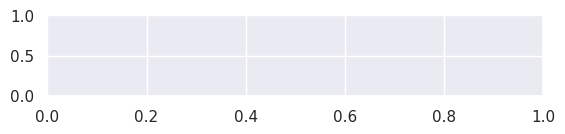

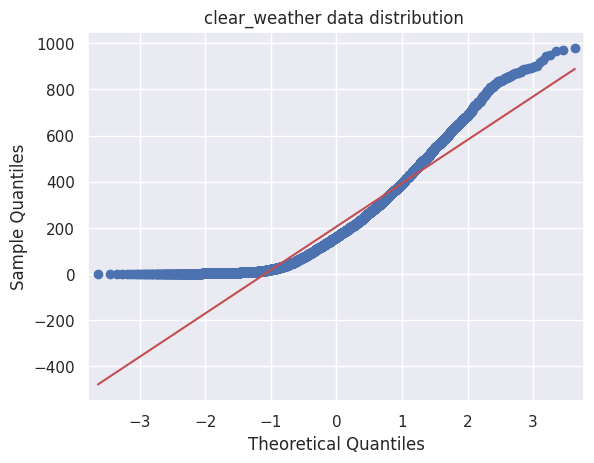

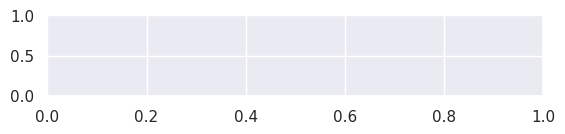

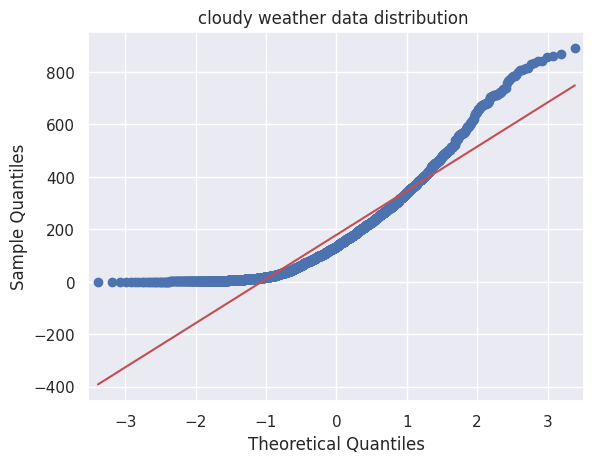

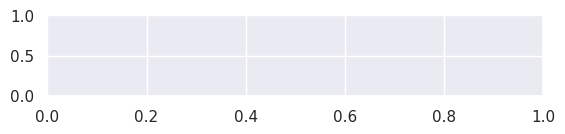

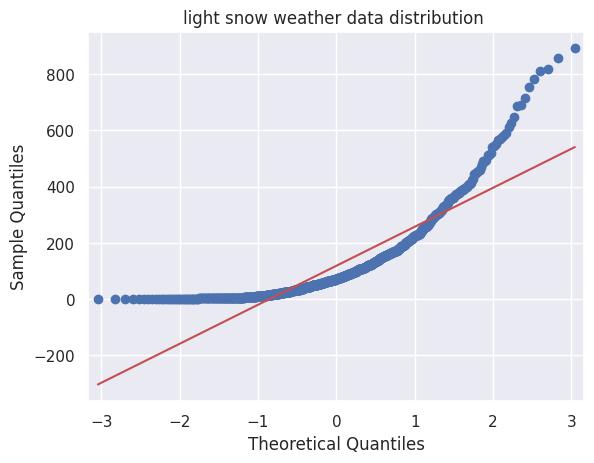

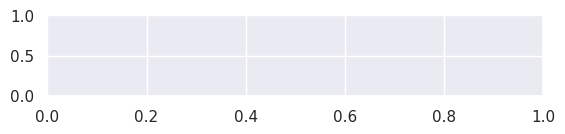

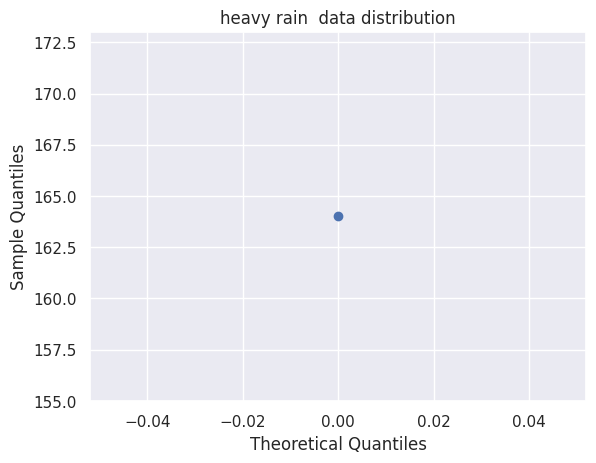

In [ ]:
clear_weather=data[(data.weather==1)]['count']
cloudy_weather=data[(data.weather==2)]['count']
light_snow=data[(data.weather==3)]['count']
heavy_rain=data[(data.weather==4)]['count']
print("avg bikes rent for clear weather :->",clear_weather.mean())
print("avg bikes for cloudy weather :->",cloudy_weather.mean())
print("avg bikes for light snow  :->",light_snow.mean())
print("avg bikes for heavy rain :->",heavy_rain.mean())

#checking normality of data with QQplot
plt.subplot(4,1,1)
qqplot(clear_weather,line='s')
plt.title('clear_weather data distribution ')
plt.show()
plt.subplot(4,1,2)
qqplot(cloudy_weather,line='s')
plt.title('cloudy weather data distribution ')
plt.show()
plt.subplot(4,1,3)
qqplot(light_snow,line='s')
plt.title('light snow weather data distribution ')
plt.show()
plt.subplot(4,1,4)
qqplot(heavy_rain,line='s')
plt.title('heavy rain  data distribution')
plt.show()

In [ ]:
'''shapiro walk's test to check normality of data:
   h0-data is normaly distributed
   ha-data is not normaly distributed'''
for i in (clear_weather,cloudy_weather,light_snow,heavy_rain):
  t_stats,p_value=shapiro(i)
  print("p value for weather group  : -",p_value)
  alpha=0.05
  if p_value<alpha:
    print("we reject null hypothesis  and can conclude that data is not  normally distributed and does not come from guassion distribution")
  else:
    print("we fail to reject null hypothesis")

p value for weather group  : - 1.5964921477006555e-57
we reject null hypothesis  and can conclude that data is not  normally distributed and does not come from guassion distribution
p value for weather group  : - 9.777839106111785e-43
we reject null hypothesis  and can conclude that data is not  normally distributed and does not come from guassion distribution
p value for weather group  : - 3.875893017396149e-33
we reject null hypothesis  and can conclude that data is not  normally distributed and does not come from guassion distribution
p value for weather group  : - nan
we fail to reject null hypothesis


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipython-input-107-1414088455.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stats,p_value=shapiro(i)


# With QQplot for different weather conditons  shows:-

 1. clear weather plot  is fluctuated from theoretical line which shows clear weather data is not normally distributed.

 2. cloudy weather data is fluctuated from theoretical line which shows cloudy weather data is not normally distributed.

 3. light snow weather data is fluctuated from theoretical line which shows light snow weather data is not normally distributed.

 4. we do not have sufficient amount of heavy rain weather data to conclude normality test for it.

 **further checked by shapiro test and found out**

 1.clear,cloudy,light rain weather  data is not normally distributed that means it's not following guassion distribution.

 2. warnings occured shows that shapiro test is not relevant for large data set.







In [ ]:
# checking equality of varience of data for all weather condition:
'''h0= varience among all groups of all weather conditions are equal
   ha=varience among all groups of all weather condition are not equal'''

levene_stats,p_value= levene(clear_weather,cloudy_weather,light_snow,heavy_rain)
print("p value:-",p_value)

alpha=0.05
if p_value<alpha:
  print("we reject null hypothesis and hence varience among all groups are not equal")
else:
  print("we accept null hypothesis")

p value:- 3.504937946833238e-35
we reject null hypothesis and hence varience among all groups are not equal


# levene's test:

shows that varience among all groups of weather condition is not same.

# conclusion of assumptions:
qqplot ,shapiro test and levene's test we can conclude that data is not normally distributed and not all groups have equal varience.that  means anova test assumptions are failed.


In [ ]:
#anova test
f_stats,p_value=f_oneway(clear_weather,cloudy_weather,light_snow,heavy_rain)
print("f statistics:-",f_stats)
print("p value:-",p_value)
alpha=0.05
if p_value<alpha:
  print("we  reject null hypothesis and all different weather conditions have different demand of bikes")
else:
  print("fail to reject null hypo")


# kruskal test : after failing anova test assumption we will go fo kruskal test
f_stats,p_value=kruskal(clear_weather,cloudy_weather,light_snow,heavy_rain)
print("f statistics:-",f_stats)
print("p value:-",p_value)
alpha=0.05
if p_value<alpha:
  print("we  reject null hypothesis and all different weather conditions have different demand of bikes")
else:
  print("fail to reject null hypo")

f statistics:- 65.53024112793271
p value:- 5.482069475935669e-42
we  reject null hypothesis and all different weather conditions have different demand of bikes
f statistics:- 205.00216514479087
p value:- 3.501611300708679e-44
we  reject null hypothesis and all different weather conditions have different demand of bikes


In [ ]:
# further we will persue t test to find which of weather condition have more rides booked:-
t1,p_clear=ttest_ind(clear_weather,cloudy_weather)
t2,p_cloudy=ttest_ind(cloudy_weather,light_snow)
t3,p_light_snow=ttest_ind(light_snow,heavy_rain)
print("p value for clear and cloudy weather",p_clear)
print("p value for cloudy and light snow weather",p_cloudy)
print("p value for light snow and heavy rain weather",p_light_snow)


p value for clear and cloudy weather 9.098916216508542e-11
p value for cloudy and light snow weather 2.7459673190273646e-21
p value for light snow and heavy rain weather 0.7447772681153065


In [ ]:
t1,p_clear=ttest_ind(clear_weather,cloudy_weather,alternative='greater')
t2,p_cloudy=ttest_ind(cloudy_weather,light_snow,alternative='greater')
print("p value for clear and cloudy weather",p_clear)
print("p value for cloudy and light snow weather",p_cloudy)
print("p value for light snow and heavy rain weather",p_light_snow)

p value for clear and cloudy weather 4.549458108254271e-11
p value for cloudy and light snow weather 1.3729836595136823e-21
p value for light snow and heavy rain weather 0.7447772681153065


# conclusion:
1. we dont have enough data to say something about heavy rain weather condition.

2. with kruskal test  we can conclude that all weather condition does not have same number of bike rides.that  there is significant statistical difference among them.

2. clear weather has more bike rides than cloudy weather.

3. cloudy weather has more bike rides than light snowy weather.

5. so overall we can say bike ride bookings in decending order for different weather condition:-

# clear weather>cloudy weather> light snowy or light rainy weather.

#Is the demand of bicycles on rent is the same for different Seasons?

**H0**-  Demand of bicyles on rent is same for differnt seasons.

**Ha**-  Demand of bicyles on rent is significantly different for different seasons.

**singnificance level alpha**=0.05 that is 5%

to check assumption we will go for one way anova test:

we'll check assumptions for anova testing:

1. data should be normally distributed.

    for checking this we will perform shapiro test and we will draw QQplot.

2. data should have equal varience in all groups.

    For check this assumption we will perform levene's test.



avg bikes for spring season :-> 116.34326135517499
avg bikes for summer season :-> 215.25137211855105
avg bikes for fall season :-> 234.417124039517
avg bikes for winter season :-> 198.98829553767374


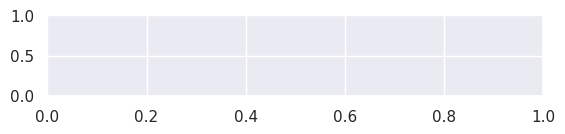

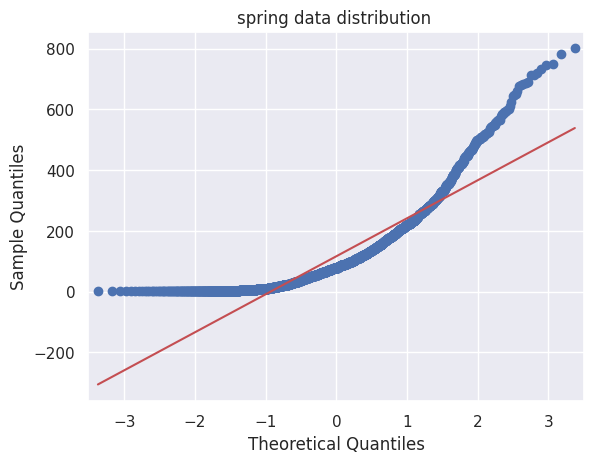

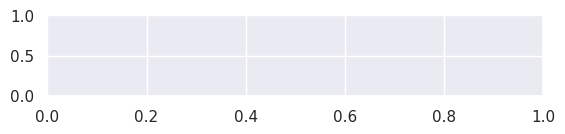

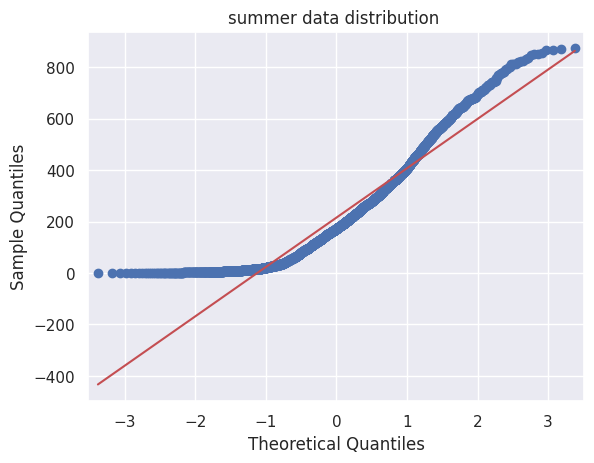

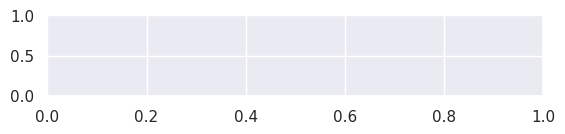

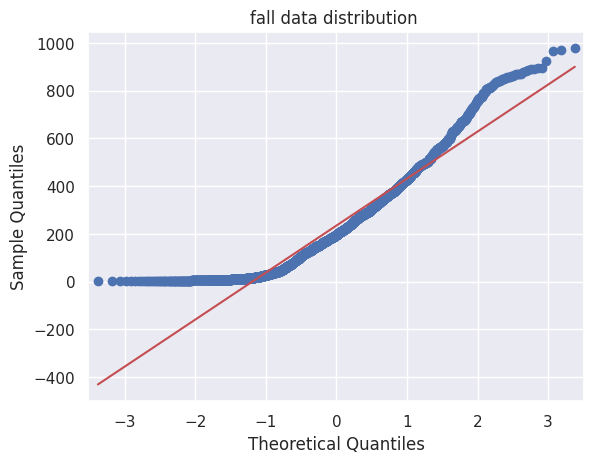

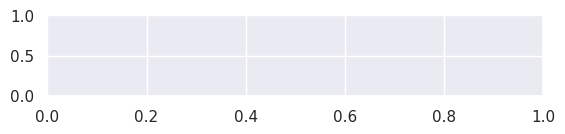

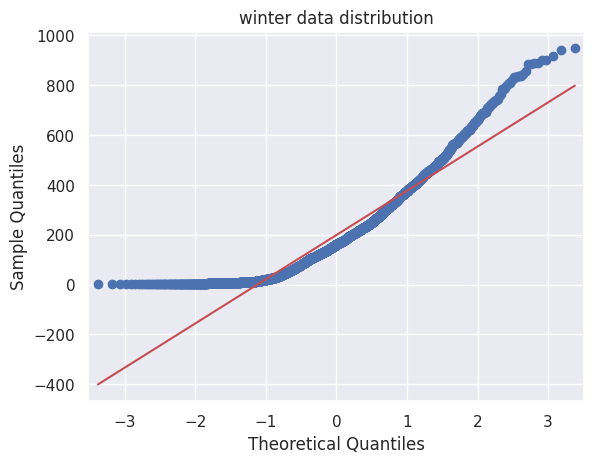

In [ ]:
spring=data[(data.season==1)]['count']
summer=data[(data.season==2)]['count']
fall=data[(data.season==3)]['count']
winter=data[(data.season==4)]['count']
print("avg bikes for spring season :->",spring.mean())
print("avg bikes for summer season :->",summer.mean())
print("avg bikes for fall season :->",fall.mean())
print("avg bikes for winter season :->",winter.mean())
#checking normality of data with QQplot
plt.subplot(4,1,1)
qqplot(spring,line='s')
plt.title('spring data distribution ')
plt.show()
plt.subplot(4,1,2)
qqplot(summer,line='s')
plt.title('summer data distribution ')
plt.show()
plt.subplot(4,1,3)
qqplot(fall,line='s')
plt.title('fall data distribution ')
plt.show()
plt.subplot(4,1,4)
qqplot(winter,line='s')
plt.title('winter data distribution')
plt.show()

In [ ]:
'''shapiro walk's test to check normality of data:
   h0-data is normaly distributed
   ha-data is not normaly distributed'''

for i in (spring,summer,fall,winter):
  t_stats,p_value=shapiro(i)
  print("p value for season : -",p_value)
  alpha=0.05
  if p_value<alpha:
    print("we reject null hypothesis  and can conclude that data is not normally distributed and does not come from guassion distribution")
  else:
    print("we accept null hypothesis")

p value for season : - 8.749584618867662e-49
we reject null hypothesis  and can conclude that data is not normally distributed and does not come from guassion distribution
p value for season : - 6.039374406270491e-39
we reject null hypothesis  and can conclude that data is not normally distributed and does not come from guassion distribution
p value for season : - 1.043680518918597e-36
we reject null hypothesis  and can conclude that data is not normally distributed and does not come from guassion distribution
p value for season : - 1.1299244409282836e-39
we reject null hypothesis  and can conclude that data is not normally distributed and does not come from guassion distribution


# With QQplot for seasons shows:-

 1. spring is fluctuated from theoretical line which shows spring season data is not normally distributed.

 2. summer is fluctuated from theoretical line which shows summer season data is not normally distributed.

 3. fall is fluctuated from theoretical line which shows fall season data is not normally distributed.

 4. winter is fluctuated from theoretical line which shows winter season data is not normally distributed.

 **further checked by shapiro test and found out**

 1. summer,fall,winter, spring season data is not normally distributed that means it's not following guassion distribution.

 2. warnings occured shows that shapiro test is not relevant for large data set.







In [ ]:
# checking equality of varience of data for all seasons:
'''h0= varience among all groups of seasons  are equal
   ha=varience among all groups of seasons  are not equal'''

levene_stats,p_value= levene(spring,summer,fall,winter)
print("p value:-",p_value)

alpha=0.05
if p_value<alpha:
  print("we reject null hypothesis and hence varience among all groups are not equal")
else:
  print("we accept null hypothesis")

p value:- 1.0147116860043298e-118
we reject null hypothesis and hence varience among all groups are not equal


# levene's test:

shows that varience among all groups of season is not same.

# conclusion of assumptions:
qqplot ,shapiro test and levene's test we can conclude that data is not normally distributed and not all groups have equal varience.that  means anova test assumptions are failed.


In [ ]:
#anova test
f_stats,p_value=f_oneway(spring,summer,fall,winter)
print("f statistics:-",f_stats)
print("p value:-",p_value)
alpha=0.05
if p_value<alpha:
  print("we  reject null hypothesis and all seasons have different demand of bikes")
else:
  print("fail to reject null hypo")


# kruskal test : after failing anova test assumption we will go fo kruskal test
f_stats,p_value=kruskal(spring,summer,fall,winter)
print("f statistics:-",f_stats)
print("p value:-",p_value)
alpha=0.05
if p_value<alpha:
  print("we  reject null hypothesis and all seasons have different demand of bikes")
else:
  print("fail to reject null hypo")

f statistics:- 236.94671081032106
p value:- 6.164843386499654e-149
we  reject null hypothesis and all seasons have different demand of bikes
f statistics:- 699.6668548181988
p value:- 2.479008372608633e-151
we  reject null hypothesis and all seasons have different demand of bikes


In [ ]:
# further we will test which two seasons shows difference in bike ride  with ttest
t1,p_spring=ttest_ind(spring,summer)
t2,p_fall=ttest_ind(summer,fall)
t3,p_winter=ttest_ind(fall,winter)
print("p value for spring and summer",p_spring)
print("p value for summer and fall",p_fall)
print("p value for fall and winter",p_winter)


p value for spring and summer 1.6578587340400095e-106
p value for summer and fall 0.00027431561172498644
p value for fall and winter 3.294359667247495e-12


In [ ]:
t1,p_spring=ttest_ind(spring,summer ,alternative='less')
t2,p_fall=ttest_ind(summer,fall,alternative='less')
t3,p_winter=ttest_ind(fall,winter,alternative='greater')
print("p value for spring and summer",p_spring)
print("p value for summer and fall",p_fall)
print("p value for fall and winter",p_winter)


p value for spring and summer 8.289293670200048e-107
p value for summer and fall 0.00013715780586249322
p value for fall and winter 1.6471798336237476e-12


# conclusion:
1.every season has different bike rents ,with t test we can say summer-spring ,summer-fall,and fall-winter all these groups have different sales.

2. spring season has less bike rides than summer.

3. summer season has less bike rides than fall season.

4. fall season has more bike ride booking than winter season.

5. so overall we can say bike ride bookings in decending order:-

# fall season>summer season > spring season>winter season.

# If the Weather conditions are significantly different during different Seasons?

**H0**-> Null hypothesis is, there is no dependency of weather and seasons on booking of bike rides.

**Ha** -> bike ride booking have no dependency on weather and season.

we will perform chi_square test to check the dependency of bike ride booking on weather and season.

In [ ]:
season_weather=pd.crosstab(data.season,data.weather)
season_weather

weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [ ]:
pd.crosstab(data.season,data.weather,margins=True)

weather,1,2,3,4,All
season,,,,,
1,1759,715,211,1,2686
2,1801,708,224,0,2733
3,1930,604,199,0,2733
4,1702,807,225,0,2734
All,7192,2834,859,1,10886


In [ ]:
# chi2 contingency tesst to check dependency of two categories are here season and weather
chi_stats,p_value,dof,expected=chi2_contingency(season_weather)
print("chi statistics:-",chi_stats)
print("p value:-",p_value)
print("degree of freedom:-",dof)
print("expected:-",expected)

chi statistics:- 49.158655596893624
p value:- 1.549925073686492e-07
degree of freedom:- 9
expected:- [[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]


In [ ]:
alpha=0.05
if p_value<alpha:
  print("reject null hypo and conclude that season has dependency on weather")
else:
  print("fail to reject null hypo")

reject null hypo and conclude that season has dependency on weather


#Conclusion:

1. with cross tab we can say mostly weather clear and cloudy.

2. weather condition and season has impact on bike ride bookings.

# Recommendations

1. There is no significant diffrence in between number of bike rides in weekdays and weekends. so yulu can have some **A/B testing** to increase bike rides in weekdays.to give some **special offer** for weekdays for some sample days to check difference .

2. fall seasons have most rides ,summer Seasons have equi rides, but spring seasons seem to decrease in bike ride rentals. Yulu should consider a **health benefit campaign** featuring bike rides in both **spring and winter seasons**.company can invest in **'winter hot rides'** compaign to increase rides.

3. clear weather and cloudy weather people are willing to take bikes but in light snowy or light rainy weather people avoid renting bikes,for this situation yulu can provide additional **raincoat to customers** with yulu bike renting for free of charge for a short amount of time to see the effect of this on customers.


